In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import faiss
import re
import string
import nltk
from nltk.stem import WordNetLemmatizer
from sentence_transformers import SentenceTransformer
from wordcloud import WordCloud


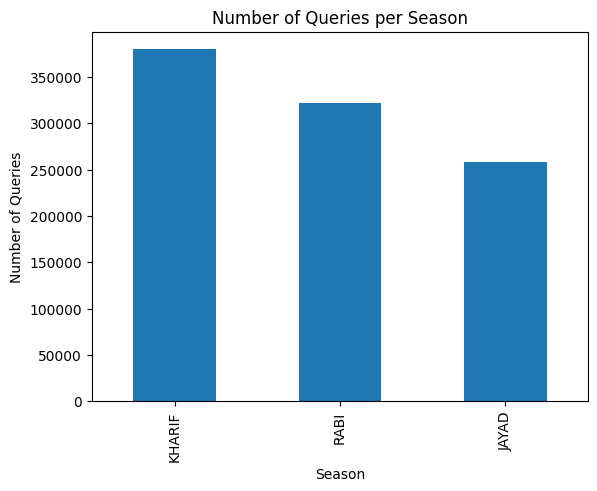

In [2]:
df = pd.read_csv("/Users/danushvdarshan/Desktop/TAMILNADU.csv", low_memory=False)

# Drop missing season or queries
season_df = df[['Season', 'QueryText']].dropna()
season_df = season_df[season_df['Season'] != '0']

# Count queries per season
season_counts = season_df['Season'].value_counts()

# Plot
season_counts.plot(kind='bar', title='Number of Queries per Season')
plt.xlabel('Season')
plt.ylabel('Number of Queries')
plt.show()


In [13]:

# Checking for total Null values in the DataFrame

df.isnull().sum()


BlockName             65
Category            1114
Year                   0
Month                  0
Day                    0
Crop                5137
DistrictName           0
QueryType          43374
Season            674352
Sector               775
StateName              0
QueryText              0
KccAns                 0
ProcessedQuery         0
dtype: int64

In [14]:

# Dropping the rows where 'QueryText' and 'Kccans' have null values.
# Reasoning is that These two are the important features for this model.
# Imputation in this case wont be appropirate as it deals with sensitive data.
# Any Mismatch can have high impact.

df = df.dropna(subset=['QueryText', 'KccAns']).reset_index(drop=True)


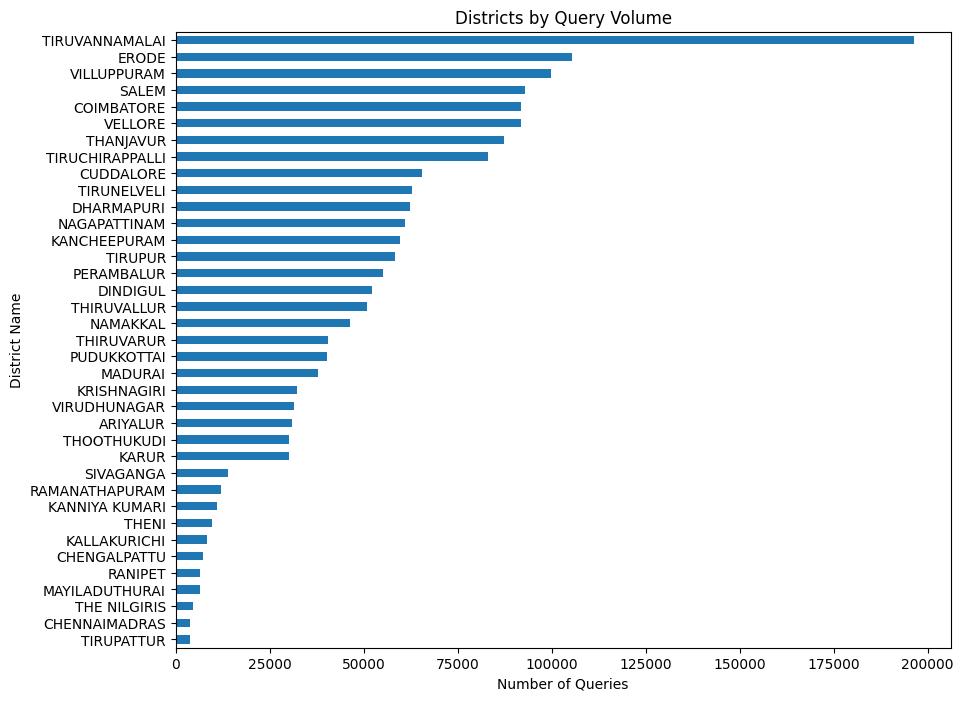

In [3]:
region_df = df[['DistrictName', 'QueryText']].dropna()

# Count queries per district
region_counts = region_df['DistrictName'].value_counts() # top 20

# Plot
region_counts.plot(kind='barh', figsize=(10,8), title='Districts by Query Volume')
plt.xlabel('Number of Queries')
plt.ylabel('District Name')
plt.gca().invert_yaxis()
plt.show()


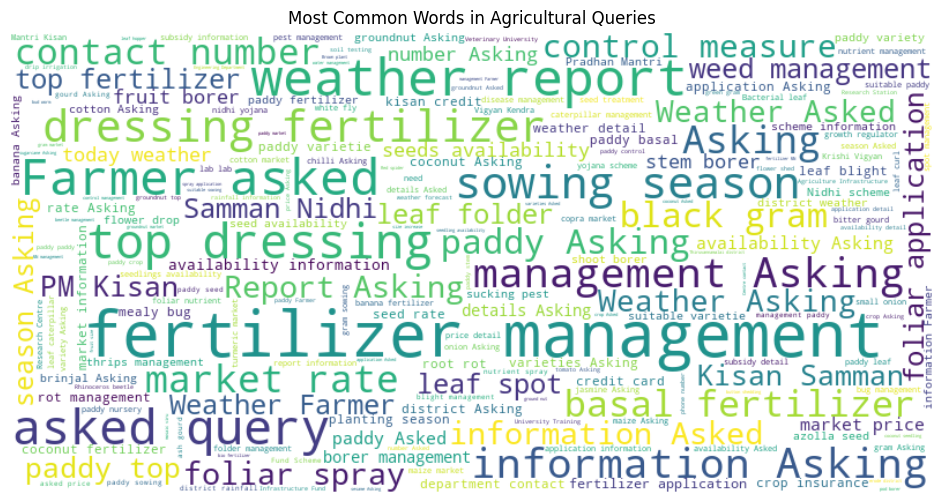

In [4]:

all_text = ' '.join(df['QueryText'].dropna().astype(str).tolist())

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Most Common Words in Agricultural Queries")
plt.show()


In [5]:
# ---------------------------
# Parameters
# ---------------------------
CSV_PATH = "/Users/danushvdarshan/Desktop/TAMILNADU.csv"  
QUERY = "fertilizer for rice"                                 # Sample Query . Change in the future, if needed
EMBEDDING_MODEL = "all-MiniLM-L6-v2"                          # Small & fast
THRESHOLD = 0.4                                               # Similarity threshold
TOP_K = 3                                                     # Fallback results count


In [6]:

print("We are now loading the data...")
df = pd.read_csv(CSV_PATH)

df = df.dropna(subset=['QueryText', 'KccAns']).reset_index(drop=True)


We are now loading the data...


/var/folders/mw/zgv_k_zn6lvfvk3fvk8c_04h0000gn/T/ipykernel_5645/1320295213.py:2: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(CSV_PATH)


In [16]:

# Map the index to data for retrieval
id_to_data = dict(enumerate(zip(df['QueryText'], df['KccAns'])))

# ---------------------------
# Preprocessing Function
# ---------------------------

# PREPROCESSING THE DATASET.
# We need to remove the punctuation in order to reduce the unnecessary dimensionality issues.
# It aids in improvement in efficiency of the model as the dimensionality is reduced.

# Lemmatizer reduces the words to its base form, Which improves the model.
# For example, words like run,runs,ran,running are converted to run. 
# Tokenizer reduces the sentence into tokens on which we can use the lemmatizer to reduce the form.

lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub(rf"[{string.punctuation}]", " ", text)  # For removing the punctuation. It is of negligible impact.
    tokens = nltk.word_tokenize(text)                     # Breaking the sentences into smaller tokens
    tokens = [lemmatizer.lemmatize(tok) for tok in tokens]
    return " ".join(tokens)

# Preprocess all queries
df['ProcessedQuery'] = df['QueryText'].apply(preprocess_text)


In [17]:

# ---------------------------
# Embedding Model
# ---------------------------

# Creating the Embedding Based Model which is faster compared to a Generative Model.
# However the Embedding Model does not provide a particularly precise answer for a general query,
# Instead it gives the answers which are closest related answer to the query.

print("Now we are generating embeddings...")

model = SentenceTransformer(EMBEDDING_MODEL)
embeddings = model.encode(df['ProcessedQuery'].tolist(), convert_to_numpy=True, show_progress_bar=True)


Now we are generating embeddings...


Batches:   0%|          | 0/52048 [00:00<?, ?it/s]

In [18]:

# ---------------------------
# Building the FAISS Index
# ---------------------------

# it is O(n) in general

print("Now we are building the FAISS Index...")

embedding_dim = embeddings.shape[1]
index = faiss.IndexFlatL2(embedding_dim)
index.add(embeddings)

print(f"FAISS index contains {index.ntotal} entries")


Now we are building the FAISS Index...
FAISS index contains 1665509 entries


In [19]:

# ---------------------------
# Query Search
# ---------------------------

print("Now we are searching the results for our Query...")

# Now we have to do the same preprocessing which we did for our training dataset. 
# To ensure we get proper results

processed_query = preprocess_text(QUERY)
query_embedding = model.encode([processed_query], convert_to_numpy=True)

distances, indices = index.search(query_embedding, TOP_K)



Now we are searching the results for our Query...


In [21]:

# ---------------------------
# Display Results
# ---------------------------

# We will the display the final results
# Allocate the threshold for the close approximity you want with the answers.

print("Now we are displaying results...")

matches_under_threshold = [(idx, dist) for idx, dist in zip(indices[0], distances[0]) if dist < THRESHOLD]

if matches_under_threshold:
    print(f"\nResults under threshold {THRESHOLD}:\n")
    for idx, dist in matches_under_threshold:
        query_text, answer_text = id_to_data[idx]
        print(f"Matched Query: {query_text}")
        print(f"Answer: {answer_text}")
        print(f"Distance: {dist:.4f}\n")
else:
    print(f"\nNo matches under the given threshold ({THRESHOLD}), showing top {TOP_K} results instead:\n")
    for idx, dist in zip(indices[0], distances[0]):
        query_text, answer_text = id_to_data[idx]
        print(f"Matched Query: {query_text}")
        print(f"Answer: {answer_text}")
        print(f"Distance: {dist:.4f}\n")


Now we are displaying results...

Results under threshold 0.4:

Matched Query: fertilizer for rice
Answer: potash
Distance: 0.0000

Matched Query: fertilizer in rice
Answer: apply urea 25kg potash 15kg neem cake 5kgac
Distance: 0.0337

Matched Query: RICE FERTILIZER
Answer: BASAL APPLICATION DAP 50KGACRE
Distance: 0.0638

